# Single-Channel PHASE Bin Demo

This notebook reads one PHASE `.bin` file, converts stored `int32` values to phase in radians, then performs filtering and plotting.

In [1]:
from pathlib import Path
import importlib

import matplotlib.pyplot as plt
import numpy as np
import phase_bin_tools as pbt

pbt = importlib.reload(pbt)

bandpass_filter = pbt.bandpass_filter
compute_point_psd = pbt.compute_point_psd
convert_phase_to_radians = pbt.convert_phase_to_radians
extract_point_waveform = pbt.extract_point_waveform
highpass_filter = pbt.highpass_filter
infer_points_per_frame_from_filename = pbt.infer_points_per_frame_from_filename
plot_point_psd = pbt.plot_point_psd
plot_point_waveform = pbt.plot_point_waveform
plot_space_time = pbt.plot_space_time
read_single_channel_phase_bin = pbt.read_single_channel_phase_bin
read_single_channel_phase_bin_raw = pbt.read_single_channel_phase_bin_raw

plt.rcParams['figure.dpi'] = 120

In [72]:
# Cell 1: configure one input file and core parameters
file_path = Path(r"0000682-eDAS-2000Hz-0130pt-20260322T141801.050.bin")
points_per_frame = infer_points_per_frame_from_filename(file_path)
scan_rate_hz = 2000.0
point_index = 100
highpass_cutoff_hz = 10.0
bandpass_low_hz = 100.0
bandpass_high_hz = 900.0

space_time_vmin = -0.1
space_time_vmax = 0.1
print(file_path)
print('points_per_frame:', points_per_frame)
print('scan_rate_hz:', scan_rate_hz)
print('point_index:', point_index)

0000682-eDAS-2000Hz-0130pt-20260322T141801.050.bin
points_per_frame: 130
scan_rate_hz: 2000.0
point_index: 100


In [ ]:
2 ms] [MainThread     ] [INFO ] pcie7821.gui        : Creating acquisition thread...
[   60209.5 ms] [MainThread     ] [INFO ] pcie7821.acq_thread : AcquisitionThread initialized with dynamic polling
[   60209.7 ms] [MainThread     ] [INFO ] pcie7821.acq_thread : Configured: total_points=61440, points_after_merge=7680, frames=2000, channels=1, data_source=4, crop=[6150, 6280)
[   60210.3 ms] [MainThread     ] [INFO ] pcie7821.gui        : Starting acquisition thread...
[   60211.0 ms] [MainThread     ] [INFO ] pcie7821.gui        : Acquisition started successfully
[   60211.2 ms] [Dummy-3        ] [INFO ] pcie7821.acq_thread : === Acquisition thread started ===



In [73]:
# Cell 2: read raw stored int32 data
frame_data_raw = read_single_channel_phase_bin_raw(file_path, points_per_frame=points_per_frame)
print('shape:', frame_data_raw.shape)
print('dtype:', frame_data_raw.dtype)
print('min/max:', frame_data_raw.min(), frame_data_raw.max())

# Cell 3: convert raw int32 values to phase in radians
frame_data_phase = convert_phase_to_radians(frame_data_raw)
print('shape:', frame_data_phase.shape)
print('dtype:', frame_data_phase.dtype)
print('min/max (rad):', frame_data_phase.min(), frame_data_phase.max())

# Cell 4: shortcut read directly as phase in radians
frame_data_phase_direct = read_single_channel_phase_bin(file_path, points_per_frame=points_per_frame)
print('same as explicit conversion:', np.allclose(frame_data_phase, frame_data_phase_direct))


# Cell 5: extract the waveform at one spatial point
waveform = extract_point_waveform(frame_data_phase, point_index)
print('waveform length:', waveform.shape[0])
waveform[:10]


# Cell 6: preprocess the waveform with a high-pass filter
waveform_hp = highpass_filter(waveform, sample_rate_hz=scan_rate_hz, cutoff_hz=highpass_cutoff_hz)
waveform_hp[:10]


# Cell 7: optional band-pass filtering
waveform_bp = bandpass_filter(
    waveform,
    sample_rate_hz=scan_rate_hz,
    lowcut_hz=bandpass_low_hz,
    highcut_hz=bandpass_high_hz,
)
waveform_bp[:10]


# Cell 8: plot the original and filtered waveform
fig, ax = plt.subplots(figsize=(10, 4))
plot_point_waveform(waveform, sample_rate_hz=scan_rate_hz, title='Original Point Waveform', ylabel='Phase (rad)', ax=ax)

fig, ax = plt.subplots(figsize=(10, 4))
plot_point_waveform(waveform_hp, sample_rate_hz=scan_rate_hz, title='High-Pass Filtered Point Waveform', ylabel='Phase (rad)', ax=ax)

fig, ax = plt.subplots(figsize=(10, 4))
plot_point_waveform(waveform_bp, sample_rate_hz=scan_rate_hz, title='Band-Pass Filtered Point Waveform', ylabel='Phase (rad)', ax=ax)

plt.show()


Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "d:\anaconda3\envs\LZdataread39\lib\site-packages\IPython\core\interactiveshell.py", line 3505, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\QiGh\AppData\Local\Temp\ipykernel_17752\2769237929.py", line 2, in <module>
    frame_data_raw = read_single_channel_phase_bin_raw(file_path, points_per_frame=points_per_frame)
  File "d:\OneDrive - EVER\00_KY\DAS-器件测试、上位机开发\BX\PCIe-7821\pcie7821_gui\read\phase_bin_tools.py", line 48, in read_single_channel_phase_bin_raw
FileNotFoundError: File not found: 0000682-eDAS-2000Hz-0130pt-20260322T141801.050.bin

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "d:\anaconda3\envs\LZdataread39\lib\site-packages\IPython\core\interactiveshell.py", line 2102, in showtraceback
    stb = self.InteractiveTB.structured_traceback(
  File "d:\anaconda3\envs\LZdataread39\lib\site-packages\IPython\core\ultratb.py", line 1310, 

In [30]:
# Cell 9: compute PSD of the selected point signal
freq_hz, psd_db = compute_point_psd(waveform_hp, sample_rate_hz=scan_rate_hz)
print('freq bins:', freq_hz.shape[0])
print('freq resolution:', freq_hz[1] - freq_hz[0])

freq bins: 20001
freq resolution: 0.1


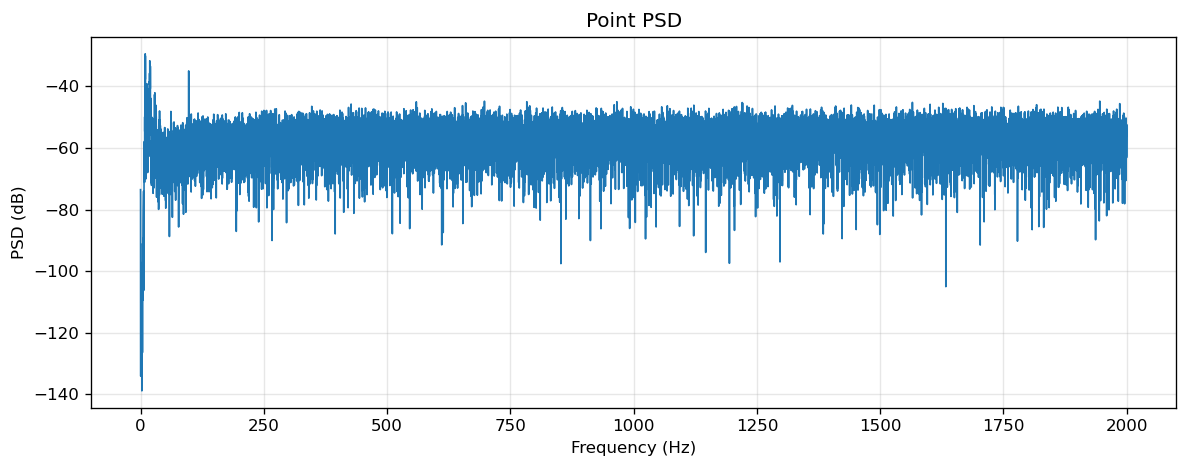

In [31]:
# Cell 10: plot the PSD result
plot_point_psd(freq_hz, psd_db, title='Point PSD')
plt.show()

In [75]:
%matplotlib qt

In [76]:
# Cell 11: draw the space-time image from phase data in radians
plot_space_time(
    frame_data_phase,
    frame_slice=slice(None),
    point_slice=slice(None),
    sample_rate_hz=scan_rate_hz,
    cmap='jet',
    title='Space-Time Plot',
    colorbar_label='Phase (rad)',
    vmin=-0.5,
    vmax=0.5,
)
plt.show()